# TOPIC MODELING HOTELES

## BARCELÓ

In [1]:
!pip install textacy spacy scikit-learn pandas numpy
!python -m spacy download es_core_news_md

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.6/321.6 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 17.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
def normalize_document(doc):
    # tokenizamos el texto
    tokens = nlp(doc)
    # quitamos puntuación/espacios/stop words y cogemos el lema en minúscula
    lemmas = [t.lemma_.lower() for t in tokens if not t.is_punct and not t.is_space and not t.is_stop]
    doc = ' '.join(lemmas)
    return doc

def normalize_corpus(corpus):
    """Normaliza un corpus de documentos aplicando la función de normalización
    normalize_document() a cada documento de la lista pasada como argumento"""
    return [normalize_document(text) for text in corpus]

# Función auxiliar para mostrar los términos más importantes de cada topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx}: "
        message += " ".join([feature_names[i]
                             for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)
    print()

In [3]:
import spacy
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

# Cargar el modelo en español
nlp = spacy.load('es_core_news_md')

Total de comentarios positivos a analizar: 324
Total de comentarios negativos a analizar: 247

Normalizando el corpus POSITIVO...
Normalizando el corpus NEGATIVO...
¡Normalización completada!


In [26]:
from IPython.display import display
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

def aplicar_topic_modeling(df, columna, n_topics=3, top_n_palabras=3):
    """
    Extrae la columna indicada del DataFrame, normaliza el texto, ajusta LSA y LDA
    y muestra DataFrames legibles extrayendo solo las palabras más importantes.
    """
    print(f"\n--- Preparando datos de la columna: '{columna}' ---")

    # 1. Extraer los textos eliminando nulos y convirtiendo a string
    corpus = df[columna].dropna().astype(str).tolist()
    print(f"Normalizando {len(corpus)} comentarios... (esto puede tardar un poco)")

    # Normalizamos (asegúrate de haber ejecutado la función normalize_corpus previamente)
    norm_corpus = normalize_corpus(corpus)

    # ==========================================
    # 1. MODELO LSA (Latent Semantic Analysis)
    # ==========================================
    tfidf_vectorizer = TfidfVectorizer(min_df=2)
    tfidf = tfidf_vectorizer.fit_transform(norm_corpus)
    lsa = TruncatedSVD(n_components=n_topics, random_state=42).fit(tfidf)
    tfidf_names = tfidf_vectorizer.get_feature_names_out()

    print("\n" + "="*50)
    print(" RESUMEN DE TOPICS LSA")
    print("="*50)
    # Mostramos las palabras principales usando la función del profesor
    print_top_words(lsa, tfidf_names, top_n_palabras)

    print("\n" + "="*50)
    print(" PESOS LSA (Solo Términos Clave)")
    print("="*50)

    # VISUALIZAR PESOS solo top words
    top_indices_globales = set() # Guardaremos los índices importantes para el DataFrame

    for topic_idx, topic in enumerate(lsa.components_):
        print(f"\nTopic #{topic_idx}:")
        # Sacamos solo los índices de las palabras con más peso
        top_indices = topic.argsort()[:-top_n_palabras - 1:-1]
        top_indices_globales.update(top_indices) # Los guardamos para luego

        # Imprimimos la palabra y su peso
        for i in top_indices:
            print(f"{tfidf_names[i]}: {topic[i]:.3f}")

    # CREAR DATAFRAME con palabras top
    top_indices_globales = list(top_indices_globales)
    top_names = [tfidf_names[i] for i in top_indices_globales]

    print("\nDATAFRAME TRANSPUESTO:")
    df_lsa = pd.DataFrame(np.round(lsa.components_[:, top_indices_globales], 4), columns=top_names).T
    display(df_lsa)

    return lsa

In [24]:
# Cargas el hotel que quieras analizar
df_hotel_barcelo = pd.read_csv('comentarios_barceló_valencia.csv')

In [30]:

lsa_positivo = aplicar_topic_modeling(df_hotel_barcelo, columna='positivo', n_topics=5,top_n_palabras=5)


--- Preparando datos de la columna: 'positivo' ---
Normalizando 312 comentarios... (esto puede tardar un poco)

 RESUMEN DE TOPICS LSA
Topic #0: ubicación desayuno habitación personal excelente
Topic #1: ubicación limpieza caminar empleado duda
Topic #2: desayuno excelente ubicacion buffet variedad
Topic #3: personal hotel excelente instalación perfecto
Topic #4: cama hotel personal cómodo desayuno


 PESOS LSA (Solo Términos Clave)

Topic #0:
ubicación: 0.789
desayuno: 0.348
habitación: 0.245
personal: 0.208
excelente: 0.170

Topic #1:
ubicación: 0.580
limpieza: 0.008
caminar: 0.007
empleado: 0.005
duda: 0.004

Topic #2:
desayuno: 0.680
excelente: 0.109
ubicacion: 0.080
buffet: 0.048
variedad: 0.037

Topic #3:
personal: 0.434
hotel: 0.380
excelente: 0.286
instalación: 0.198
perfecto: 0.183

Topic #4:
cama: 0.603
hotel: 0.212
personal: 0.161
cómodo: 0.142
desayuno: 0.123

DATAFRAME TRANSPUESTO:


,0,1,2,3,4
empleado,0.0089,0.0054,-0.0042,-0.0014,0.0031
limpieza,0.1506,0.0084,0.0120,0.0093,-0.0355
perfecto,0.0670,-0.0785,-0.0472,0.1829,0.0276
buffet,0.0499,-0.0290,0.0483,0.0224,0.0478
personal,0.2081,-0.1147,-0.0890,0.4345,0.1614
habitación,0.2450,-0.3211,-0.3585,-0.2505,-0.5890
ubicacion,0.0189,-0.0562,0.0796,0.0122,-0.0002
ubicación,0.7890,0.5803,-0.0007,-0.0935,0.0353
hotel,0.0946,-0.1411,-0.1658,0.3801,0.2118
cama,0.1038,-0.2110,-0.3896,-0.3462,0.6025


In [29]:
lsa_negativo = aplicar_topic_modeling(df_hotel_barcelo, columna='negativo', n_topics=5,top_n_palabras=5)


--- Preparando datos de la columna: 'negativo' ---
Normalizando 223 comentarios... (esto puede tardar un poco)

 RESUMEN DE TOPICS LSA
Topic #0: habitación ducha pequeño piscina baño
Topic #1: piscina pequeño gimnasio persona azotea
Topic #2: ducha agua bañera caliente plato
Topic #3: caro desayuno precio ducha agua
Topic #4: gustar parking hotel habitacion incómodo


 PESOS LSA (Solo Términos Clave)

Topic #0:
habitación: 0.515
ducha: 0.275
pequeño: 0.275
piscina: 0.274
baño: 0.236

Topic #1:
piscina: 0.634
pequeño: 0.574
gimnasio: 0.127
persona: 0.088
azotea: 0.069

Topic #2:
ducha: 0.433
agua: 0.367
bañera: 0.163
caliente: 0.142
plato: 0.109

Topic #3:
caro: 0.460
desayuno: 0.456
precio: 0.220
ducha: 0.204
agua: 0.194

Topic #4:
gustar: 0.857
parking: 0.268
hotel: 0.096
habitacion: 0.095
incómodo: 0.066

DATAFRAME TRANSPUESTO:


,0,1,2,3,4
hotel,0.1752,0.0264,-0.0437,0.1183,0.0960
incómodo,0.0485,-0.0207,-0.0121,0.0343,0.0656
agua,0.1898,-0.0891,0.3673,0.1938,-0.0082
azotea,0.0410,0.0685,-0.0044,-0.0063,0.0070
bañera,0.0939,-0.0321,0.1625,0.0878,-0.0723
baño,0.2355,-0.1260,0.0816,-0.0348,-0.1735
caliente,0.0854,-0.0159,0.1415,0.0775,0.0307
caro,0.0729,0.0125,-0.3501,0.4602,-0.1234
parking,0.0607,-0.0237,-0.0500,0.1254,0.2677
pequeño,0.2753,0.5740,0.0140,-0.0956,0.0140


### CASUAL VINTAGE

In [32]:
df_hotel_casual = pd.read_csv('comentarios_casual_vintage_valencia.csv')

In [33]:
lsa_positivo = aplicar_topic_modeling(df_hotel_casual, columna='positivo', n_topics=5,top_n_palabras=5)


--- Preparando datos de la columna: 'positivo' ---
Normalizando 1052 comentarios... (esto puede tardar un poco)

 RESUMEN DE TOPICS LSA
Topic #0: ubicación personal excelente habitación desayuno
Topic #1: personal excelente habitación desayuno cómodo
Topic #2: ubicacion excelente desayuno habitacion atencion
Topic #3: personal excelente atención amable trato
Topic #4: excelente desayuno céntrico correcto instalación


 PESOS LSA (Solo Términos Clave)

Topic #0:
ubicación: 0.962
personal: 0.139
excelente: 0.136
habitación: 0.084
desayuno: 0.078

Topic #1:
personal: 0.450
excelente: 0.344
habitación: 0.341
desayuno: 0.294
cómodo: 0.224

Topic #2:
ubicacion: 0.812
excelente: 0.380
desayuno: 0.062
habitacion: 0.037
atencion: 0.031

Topic #3:
personal: 0.537
excelente: 0.231
atención: 0.175
amable: 0.128
trato: 0.110

Topic #4:
excelente: 0.730
desayuno: 0.209
céntrico: 0.037
correcto: 0.027
instalación: 0.026

DATAFRAME TRANSPUESTO:


,0,1,2,3,4
correcto,0.0103,0.0415,-0.0013,0.0048,0.0270
trato,0.0287,0.0945,-0.0655,0.1104,-0.0214
ubicacion,0.0085,0.1898,0.8122,0.0296,-0.5242
ubicación,0.9616,-0.2608,0.0219,-0.0300,-0.0449
personal,0.1388,0.4504,-0.3038,0.5369,-0.2556
atencion,0.0019,0.0193,0.0312,0.0157,-0.0186
atención,0.0523,0.1464,-0.1610,0.1754,-0.1420
cómodo,0.0404,0.2243,-0.0755,-0.2436,0.0053
céntrico,0.0168,0.0805,-0.0111,-0.0396,0.0368
excelente,0.1358,0.3443,0.3803,0.2314,0.7302


In [34]:
lsa_negativo = aplicar_topic_modeling(df_hotel_casual, columna='negativo', n_topics=5,top_n_palabras=5)


--- Preparando datos de la columna: 'negativo' ---
Normalizando 731 comentarios... (esto puede tardar un poco)

 RESUMEN DE TOPICS LSA
Topic #0: habitación pequeño baño ruido ascensor
Topic #1: desayuno ruido escaso variedad calidad
Topic #2: ruido calle escuchar noche oir
Topic #3: baño ruido calle ascensor antiguo
Topic #4: ascensor pequeño lento ruido espera


 PESOS LSA (Solo Términos Clave)

Topic #0:
habitación: 0.573
pequeño: 0.348
baño: 0.274
ruido: 0.256
ascensor: 0.209

Topic #1:
desayuno: 0.805
ruido: 0.178
escaso: 0.140
variedad: 0.131
calidad: 0.086

Topic #2:
ruido: 0.620
calle: 0.342
escuchar: 0.154
noche: 0.150
oir: 0.123

Topic #3:
baño: 0.660
ruido: 0.344
calle: 0.188
ascensor: 0.175
antiguo: 0.109

Topic #4:
ascensor: 0.805
pequeño: 0.180
lento: 0.130
ruido: 0.085
espera: 0.059

DATAFRAME TRANSPUESTO:


,0,1,2,3,4
lento,0.0356,-0.0181,-0.0255,0.0338,0.1301
baño,0.2741,-0.2810,-0.3419,0.6596,-0.4161
pequeño,0.3484,-0.2578,-0.2112,-0.1044,0.1799
desayuno,0.2082,0.8054,-0.3762,0.0713,0.0285
oir,0.0612,0.0299,0.1234,0.0895,0.0330
ruido,0.2561,0.1785,0.6198,0.3444,0.0849
antiguo,0.0881,-0.0517,-0.0378,0.1085,-0.0991
habitación,0.5730,-0.0561,0.0615,-0.4685,-0.1832
escaso,0.0393,0.1400,-0.0723,0.0030,-0.0005
ascensor,0.2094,-0.1743,-0.1961,0.1749,0.8045


In [35]:
!pip install wordcloud matplotlib seaborn

Generando WordClouds...


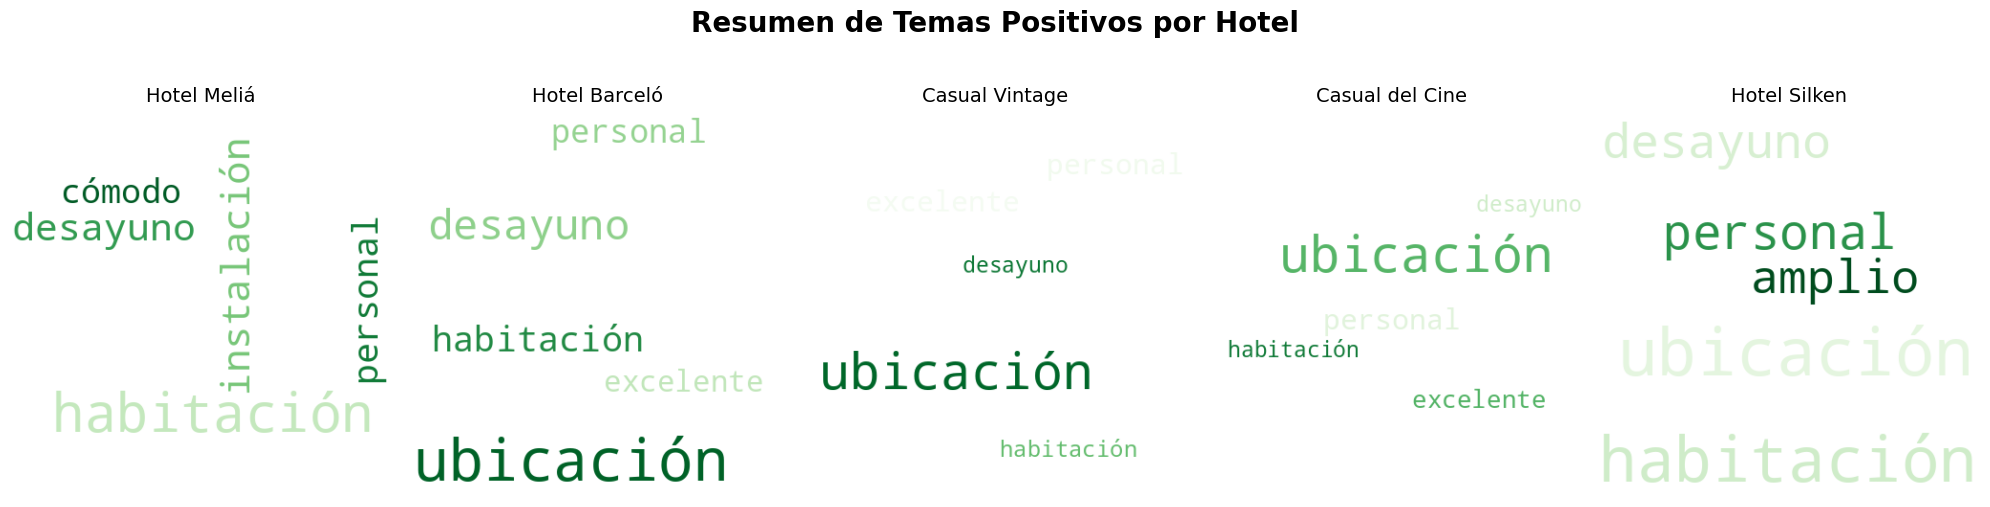

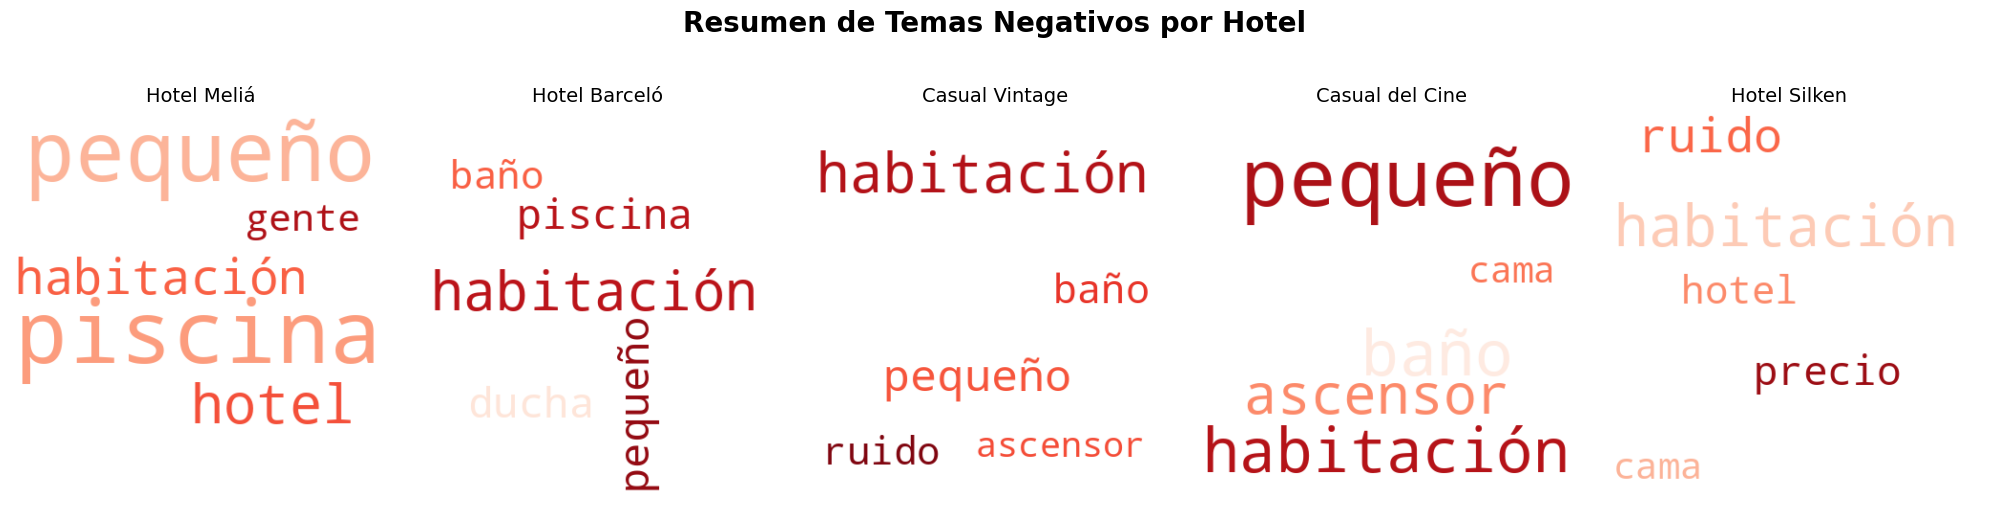

Generando Gráficos de Barras...


/tmp/ipykernel_2971/1585678354.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Palabra', data=df_temp, ax=axes[i], palette=color)
/tmp/ipykernel_2971/1585678354.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Palabra', data=df_temp, ax=axes[i], palette=color)
/tmp/ipykernel_2971/1585678354.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Palabra', data=df_temp, ax=axes[i], palette=color)
/tmp/ipykernel_2971/1585678354.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is dep

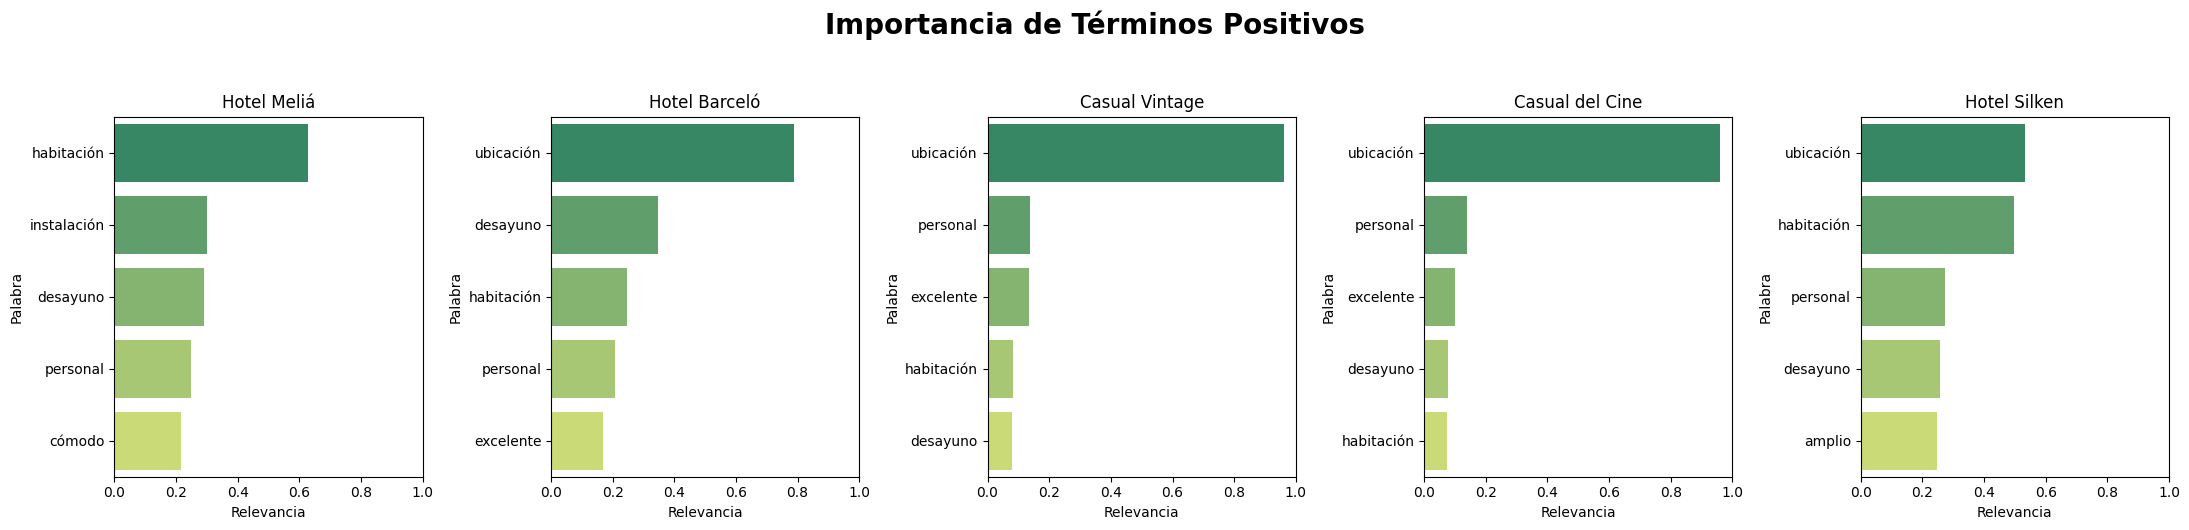

/tmp/ipykernel_2971/1585678354.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Palabra', data=df_temp, ax=axes[i], palette=color)
/tmp/ipykernel_2971/1585678354.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Palabra', data=df_temp, ax=axes[i], palette=color)
/tmp/ipykernel_2971/1585678354.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Palabra', data=df_temp, ax=axes[i], palette=color)
/tmp/ipykernel_2971/1585678354.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is dep

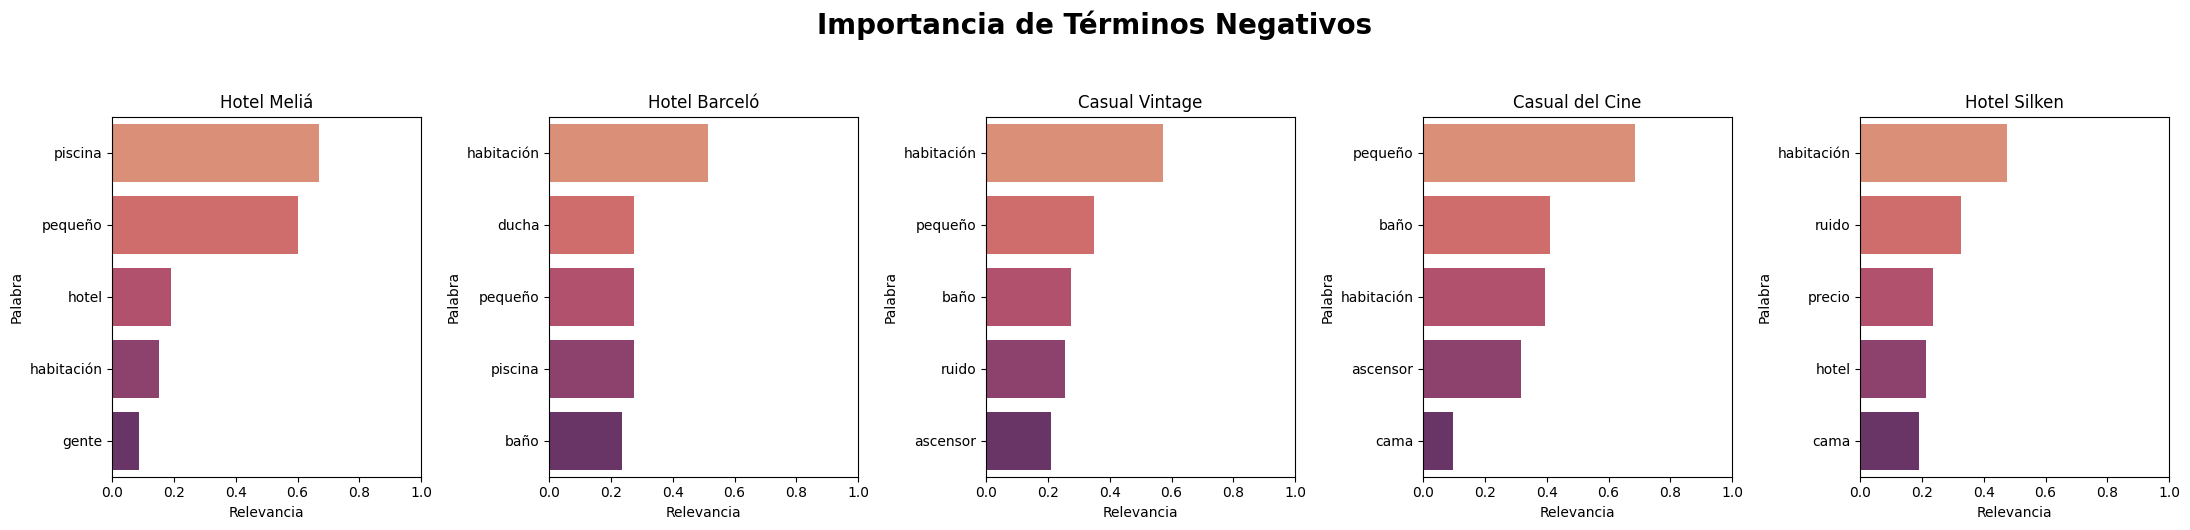

In [36]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
import seaborn as sns

# ========================================================
# 1. DATOS EXTRAÍDOS MANUALMENTE DE TUS RESULTADOS
# ========================================================
datos_hoteles = {
    "Hotel Meliá": {
        "Positivo": {"habitación": 0.629, "instalación": 0.301, "desayuno": 0.292, "personal": 0.248, "cómodo": 0.216},
        "Negativo": {"piscina": 0.669, "pequeño": 0.603, "hotel": 0.191, "habitación": 0.152, "gente": 0.085}
    },
    "Hotel Barceló": {
        "Positivo": {"ubicación": 0.789, "desayuno": 0.348, "habitación": 0.245, "personal": 0.208, "excelente": 0.170},
        "Negativo": {"habitación": 0.515, "ducha": 0.275, "pequeño": 0.275, "piscina": 0.274, "baño": 0.236}
    },
    "Casual Vintage": {
        "Positivo": {"ubicación": 0.962, "personal": 0.139, "excelente": 0.136, "habitación": 0.084, "desayuno": 0.078},
        "Negativo": {"habitación": 0.573, "pequeño": 0.348, "baño": 0.274, "ruido": 0.256, "ascensor": 0.209}
    },
    "Casual del Cine": {
        "Positivo": {"ubicación": 0.960, "personal": 0.138, "excelente": 0.100, "desayuno": 0.078, "habitación": 0.075},
        "Negativo": {"pequeño": 0.687, "baño": 0.410, "habitación": 0.394, "ascensor": 0.317, "cama": 0.097}
    },
    "Hotel Silken": {
        "Positivo": {"ubicación": 0.534, "habitación": 0.498, "personal": 0.272, "desayuno": 0.256, "amplio": 0.249},
        "Negativo": {"habitación": 0.476, "ruido": 0.325, "precio": 0.234, "hotel": 0.212, "cama": 0.191}
    }
}

# ========================================================
# 2. FUNCIÓN PARA GENERAR WORDCLOUDS (IDEAL PARA CANVA)
# ========================================================
def generar_nubes_resumen(datos, sentimiento="Positivo", color_map="Greens"):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(f"Resumen de Temas {sentimiento}s por Hotel", fontsize=20, fontweight='bold', y=1.05)

    for i, (hotel, sentiment_data) in enumerate(datos.items()):
        pesos = sentiment_data[sentimiento]
        # Generar nube
        wc = WordCloud(background_color='white', width=400, height=400, colormap=color_map).generate_from_frequencies(pesos)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(hotel, fontsize=14, pad=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# ========================================================
# 3. FUNCIÓN PARA GENERAR BARRAS DE PORCENTAJES
# ========================================================
def generar_barras_resumen(datos, sentimiento="Positivo", color="viridis"):
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle(f"Importancia de Términos {sentimiento}s", fontsize=20, fontweight='bold', y=1.05)

    for i, (hotel, sentiment_data) in enumerate(datos.items()):
        pesos = sentiment_data[sentimiento]
        df_temp = pd.DataFrame(list(pesos.items()), columns=['Palabra', 'Peso']).sort_values(by='Peso', ascending=False)

        sns.barplot(x='Peso', y='Palabra', data=df_temp, ax=axes[i], palette=color)
        axes[i].set_title(hotel)
        axes[i].set_xlabel("Relevancia")
        axes[i].set_xlim(0, 1) # Normalizamos escala de 0 a 1

    plt.tight_layout()
    plt.show()

# ========================================================
# EJECUCIÓN: Genera las imágenes para copiar a tu Canva
# ========================================================

# Nubes de palabras
print("Generando WordClouds...")
generar_nubes_resumen(datos_hoteles, "Positivo", "Greens")
generar_nubes_resumen(datos_hoteles, "Negativo", "Reds")

# Gráficos de barras (si prefieres precisión numérica)
print("Generando Gráficos de Barras...")
generar_barras_resumen(datos_hoteles, "Positivo", "summer")
generar_barras_resumen(datos_hoteles, "Negativo", "flare")